# 0. What decision trees are
* a subset of machine learning approaches (one other approach, for example, is neural networks);
* a superset and the foundation of different algorithms e.g. random forests and gradient boosting;
* among the easiest to understand;
* among the most readily interpretable;
* as white as boxes can be (as opposed to black boxes).

# What decision trees aren't
* child's play;
* for beginners only.

In fact implementations such as *LightGBM* and *XGBoost* frequently score top in Kaggle competitions! 

In this notebook we shall gently walkthrough leaf by leaf, tree by tree. I use LightGBM here; the same principle applies to decision trees in general.

# 1. Initiation rite
Invocations we can't go on without.

In [1]:
import pandas as pd
import lightgbm as lgb

# 2. Toy data & toy model 
Borrowing data from https://www.kaggle.com/uciml/iris.
*Replace next cell with your own data.*

In [2]:
import os
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

train = pd.read_csv('/kaggle/input/iris/Iris.csv', index_col='Id')
dataX = train[ train.columns[train.columns.str.contains('Cm$')] ]
datay = OrdinalEncoder().fit_transform(train[['Species']]).flatten().astype(int)
trainSet = lgb.Dataset(dataX, datay)

param = {'objective'       : 'multiclass',
         'metric'          : 'multi_logloss',
         'num_class'       : train['Species'].nunique(),
         'num_leaves'      : 3,
         'min_data_in_leaf': 36, 
         'learning_rate'   : .15,
         'num_boost_round' : 30}
model = lgb.train(param, trainSet)

/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


# 3. Put trees in Pandas DataFrame
Skip the next cell unless you are particularly interested! The original notebook where I wrote these[](http://) functions is available from https://www.kaggle.com/marychin/lightgbm-trees-to-pandas-dataframe.

In [3]:
def grabdict(tisdict, tree_index, split_index, depth, splits, leaves):
# recursive function to unravel nested dictionaries
    depth += 1
    if 'split_index' in tisdict.keys():
        tis = tisdict.copy()
        del tis['left_child']
        del tis['right_child']
        tis['tree_index'] = tree_index
        split_index = tis['split_index']
        splits = pd.concat([splits, pd.DataFrame(tis, index=[len(splits)])])
        splits, leaves = grabdict(tisdict['left_child'], tree_index, split_index, depth, splits, leaves)
        splits, leaves = grabdict(tisdict['right_child'], tree_index, split_index, depth, splits, leaves)
    else:
        tis = tisdict.copy()
        tis['tree_index'] = tree_index
        tis['split_index'] = split_index
        tis['depth'] = depth
        leaves = pd.concat([leaves, pd.DataFrame(tis, index=[len(leaves)])])
    return splits, leaves

def grabtrees(model):
# wrapper function to call the two functions above
    splits, leaves = pd.DataFrame(), pd.DataFrame()
    tree_info = model.dump_model()['tree_info']
    for tisdict in tree_info:
        splits, leaves = grabdict(tisdict['tree_structure'], tisdict['tree_index'], 0, 0, splits, leaves)
    leaves = leaves.merge(splits, left_on=['tree_index', 'split_index'], right_on=['tree_index', 'split_index'], how='left')
    return tree_info, leaves

tree_info, leaves = grabtrees(model)
leaves   # all leaves in a single df: one leaf per row

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
0,0,-0.880230,22.666667,51,0,0,2,2,72.794098,3.15,<=,True,None,0.000000,0.00000,150
1,1,-1.211112,44.000000,99,0,0,2,2,72.794098,3.15,<=,True,None,0.000000,0.00000,150
2,0,-1.211112,21.333333,48,1,0,2,2,17.647100,1.80,<=,True,None,0.000000,0.00000,150
3,1,-0.911112,24.000000,54,1,1,3,3,41.040401,1.65,<=,True,None,0.352941,45.33330,102
4,2,-1.197050,21.333333,48,1,1,3,3,41.040401,1.65,<=,True,None,0.352941,45.33330,102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,2,0.035329,7.042271,67,88,1,3,0,0.437202,5.15,<=,True,None,0.116708,9.11514,108
265,1,-0.038361,2.884964,42,88,0,2,2,0.303985,5.05,<=,True,None,0.000000,0.00000,150
266,0,-0.076539,1.213377,36,89,1,3,1,0.000018,3.05,<=,True,None,-0.508155,1.73031,78
267,2,-0.075481,0.516935,42,89,1,3,1,0.000018,3.05,<=,True,None,-0.508155,1.73031,78


# 4. A quick bird's-eye tour

In [4]:
# How many trees altogether?
how_many_trees = len(tree_info)
assert how_many_trees == param['num_boost_round'] * param['num_class']
how_many_trees

90

In [5]:
leaves.describe()

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,internal_value,internal_weight,internal_count
count,269.000000,269.000000,269.000000,269.000000,269.000000,269.00000,269.00000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000
mean,0.996283,-0.055894,10.225954,50.185874,44.665428,0.66171,2.66171,1.933086,5.114435,3.040706,-0.180426,12.319625,116.304833
std,0.817249,0.196510,7.601834,8.746579,25.933316,0.47401,0.47401,0.963505,11.129747,1.703784,0.300671,13.838413,24.914106
min,0.000000,-1.211112,0.516935,36.000000,0.000000,0.00000,2.00000,0.000000,0.000012,0.350000,-0.709556,0.000000,78.000000
25%,0.000000,-0.081765,3.816952,46.000000,22.000000,0.00000,2.00000,1.000000,0.056336,1.650000,-0.509746,0.000000,99.000000
50%,1.000000,-0.073226,8.550356,48.000000,45.000000,1.00000,3.00000,2.000000,0.704565,3.050000,0.000000,8.084560,102.000000
75%,2.000000,0.046124,15.166012,55.000000,67.000000,1.00000,3.00000,3.000000,4.174600,4.750000,0.000000,20.553500,150.000000
max,2.000000,0.177726,44.000000,99.000000,89.000000,1.00000,3.00000,3.000000,72.794098,6.250000,0.352941,45.874500,150.000000


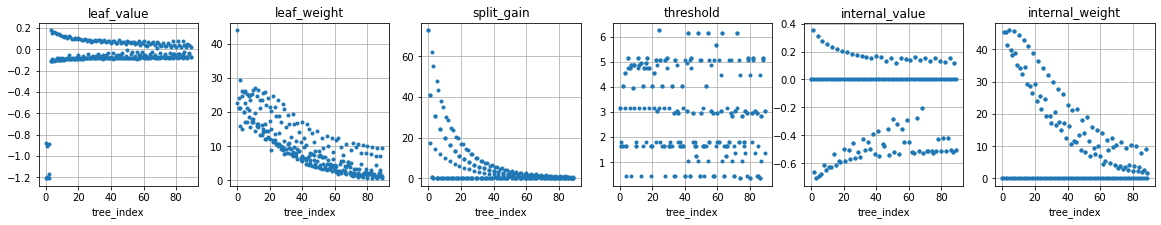

In [6]:
import matplotlib.pyplot as plt
cols = leaves.select_dtypes(include='float').columns
plt.figure(figsize=(20, 3))
for ncol, col in enumerate(cols):
    plt.subplot(1, len(cols), 1+ncol)
    plt.plot(leaves['tree_index'], leaves[col], '.')
    plt.title(col); plt.grid(True); plt.xlabel('tree_index')
# Never mind the details. Suffice to note at this point that the 90 trees we get are not independent. There is a clear monotonic trend towards convergence.

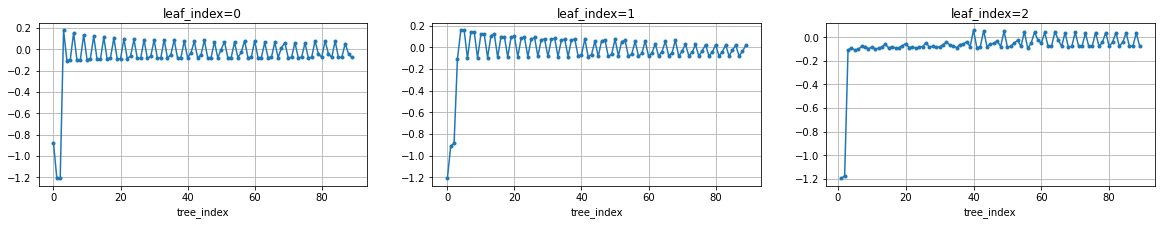

In [7]:
plt.figure(figsize=(20, 3))
for nleaf_index, leaf_index in enumerate(leaves['leaf_index'].unique()):
    plt.subplot(1, leaves['leaf_index'].nunique(), 1+nleaf_index)
    select = leaves['leaf_index']==leaf_index
    plt.plot(leaves.loc[select, 'tree_index'], leaves.loc[select, 'leaf_value'], '.-')
    plt.xlabel('tree_index')
    plt.title(f'leaf_index={leaf_index}')
    plt.grid(True)

# 5. Case study (*Tree* study, rather)

In [8]:
# our first tree
leaves.loc[ leaves['tree_index']==0 ]

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
0,0,-0.880230,22.666667,51,0,0,2,2,72.794098,3.15,<=,True,None,0.0,0.0,150
1,1,-1.211112,44.000000,99,0,0,2,2,72.794098,3.15,<=,True,None,0.0,0.0,150


In [9]:
tree_info[0]

{'tree_index': 0,
 'num_leaves': 2,
 'num_cat': 0,
 'shrinkage': 1,
 'tree_structure': {'split_index': 0,
  'split_feature': 2,
  'split_gain': 72.79409790039062,
  'threshold': 3.1500000000000004,
  'decision_type': '<=',
  'default_left': True,
  'missing_type': 'None',
  'internal_value': 0,
  'internal_weight': 0,
  'internal_count': 150,
  'left_child': {'leaf_index': 0,
   'leaf_value': -0.8802299308457074,
   'leaf_weight': 22.666666835546494,
   'leaf_count': 51},
  'right_child': {'leaf_index': 1,
   'leaf_value': -1.2111122911826806,
   'leaf_weight': 44.000000327825546,
   'leaf_count': 99}}}

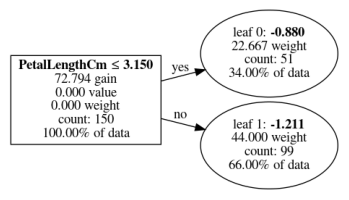

In [10]:
show_info = ['split_gain', 'internal_value', 'internal_weight', 'internal_count', 'leaf_weight', 'leaf_count', 'data_percentage']
lgb.plot_tree(model, tree_index=0, show_info=show_info)
# Here we find 1 split (square) and 2 leaves (oval). This is a tree in its simplest form. More complicated trees later.

### 5.1 Inside the box
* Where does PetalLengthCm come from?
* Where does 3.150 come from?
* Where do 72.794 gain, 0.000 value, 0.000 weight, count: 150, 100% of data come from?

In [11]:
model.feature_name()[tree_info[0]['tree_structure']['split_feature']]

'PetalLengthCm'

In [12]:
leaves.loc[ leaves['tree_index']==0 ][['threshold', 'split_gain', 'internal_value', 'internal_weight', 'internal_count']]
# These values are characteristic of the split. Therefore shared in common by both leaves.

,threshold,split_gain,internal_value,internal_weight,internal_count
0,3.15,72.794098,0.0,0.0,150
1,3.15,72.794098,0.0,0.0,150


In [13]:
tree_info[0]['tree_structure']['threshold']

3.1500000000000004

In [14]:
tree_info[0]['tree_structure']['split_gain']

72.79409790039062

In [15]:
tree_info[0]['tree_structure']['internal_value']

0

In [16]:
tree_info[0]['tree_structure']['internal_weight']

0

In [17]:
tree_info[0]['tree_structure']['internal_count']

150

In [18]:
tree_info[0]['tree_structure']['internal_count'] / len(dataX) * 100

100.0

### 5.2 The top leaf
* Where does -0.880 come from?
* Where do 22.667 weight, count: 51, 34.00% of data come from?

In [19]:
leaves.loc[ (leaves['tree_index']==0) & (leaves['leaf_index']==0)]

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
0,0,-0.88023,22.666667,51,0,0,2,2,72.794098,3.15,<=,True,None,0.0,0.0,150


In [20]:
tree_info[0]['tree_structure']['left_child']

{'leaf_index': 0,
 'leaf_value': -0.8802299308457074,
 'leaf_weight': 22.666666835546494,
 'leaf_count': 51}

In [21]:
tree_info[0]['tree_structure']['left_child']['leaf_count'] / len(dataX) * 100

34.0

In [22]:
(dataX['PetalLengthCm']<=3.15).sum(),   leaves.loc[ (leaves['tree_index']==0) & (leaves['leaf_index']==0), 'leaf_count'].values

(51, array([51]))

### 5.3 The bottom leaf
* Where does -1.211 come from?
* Where edo 44.000 weight, count: 99, 66.00% of data come from?

In [23]:
leaves.loc[ (leaves['tree_index']==0) & (leaves['leaf_index']==1)]

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
1,1,-1.211112,44.0,99,0,0,2,2,72.794098,3.15,<=,True,None,0.0,0.0,150


In [24]:
tree_info[0]['tree_structure']['right_child']

{'leaf_index': 1,
 'leaf_value': -1.2111122911826806,
 'leaf_weight': 44.000000327825546,
 'leaf_count': 99}

In [25]:
tree_info[0]['tree_structure']['right_child']['leaf_count'] / len(dataX) * 100

66.0

In [26]:
(dataX['PetalLengthCm']>3.15).sum(),   leaves.loc[ (leaves['tree_index']==0) & (leaves['leaf_index']==1), 'leaf_count'].values

(99, array([99]))

* Do leaf counts add up to the count in the parent node?

In [27]:
tree_info[0]['tree_structure']['internal_count'] == \
tree_info[0]['tree_structure']['left_child']['leaf_count'] + \
tree_info[0]['tree_structure']['right_child']['leaf_count']
# Yes!

True

# 6. Jump to our last tree

In [28]:
leaves.loc[ leaves['tree_index'] == leaves['tree_index'].max() ]

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
266,0,-0.076539,1.213377,36,89,1,3,1,0.000018,3.05,<=,True,None,-0.508155,1.73031,78
267,2,-0.075481,0.516935,42,89,1,3,1,0.000018,3.05,<=,True,None,-0.508155,1.73031,78
268,1,0.018007,9.324759,72,89,0,2,3,0.575968,1.35,<=,True,None,0.000000,0.00000,150


In [29]:
tree_info[-1]
# See that num_leaves=3 so we rightly found 3 leaves in the previous cell

{'tree_index': 89,
 'num_leaves': 3,
 'num_cat': 0,
 'shrinkage': 0.15,
 'tree_structure': {'split_index': 0,
  'split_feature': 3,
  'split_gain': 0.5759680271148682,
  'threshold': 1.3500000000000003,
  'decision_type': '<=',
  'default_left': True,
  'missing_type': 'None',
  'internal_value': 0,
  'internal_weight': 0,
  'internal_count': 150,
  'left_child': {'split_index': 1,
   'split_feature': 1,
   'split_gain': 1.8038499547401443e-05,
   'threshold': 3.0500000000000003,
   'decision_type': '<=',
   'default_left': True,
   'missing_type': 'None',
   'internal_value': -0.508155,
   'internal_weight': 1.73031,
   'internal_count': 78,
   'left_child': {'leaf_index': 0,
    'leaf_value': -0.076539370348197,
    'leaf_weight': 1.2133770901709802,
    'leaf_count': 36},
   'right_child': {'leaf_index': 2,
    'leaf_value': -0.07548124482101065,
    'leaf_weight': 0.5169354565441607,
    'leaf_count': 42}},
  'right_child': {'leaf_index': 1,
   'leaf_value': 0.018006921453854272,
 

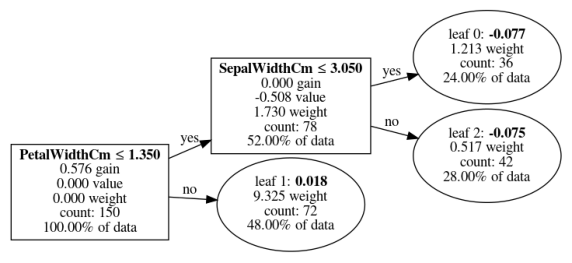

In [30]:
lgb.plot_tree(model, tree_index=89, figsize=(10, 10), show_info=show_info)
# Here we find 2 splits (square) and 3 leaves (oval).
# Leaf count is 3, consistent with the output from the previous 2 cells.

### 6.1 The 1st split (split_index=0)

In [31]:
leaves.loc[ (leaves['tree_index']==89) & (leaves['split_index']==0) ]
* Note that each box splits into two. Always two: either Yes or No. Not one. Not more.

SyntaxError: invalid syntax (<ipython-input-31-22d3fcb62c7e>, line 2)

### 6.2 The 2nd split (split_index=1)

In [32]:
leaves.loc[ (leaves['tree_index']==89) & (leaves['split_index']==1) ]

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
266,0,-0.076539,1.213377,36,89,1,3,1,0.000018,3.05,<=,True,None,-0.508155,1.73031,78
267,2,-0.075481,0.516935,42,89,1,3,1,0.000018,3.05,<=,True,None,-0.508155,1.73031,78


### 6.3 The 1st leaf (leaf_index=0, count=36)

In [33]:
sum((dataX['PetalWidthCm']<=1.35) & \
    (dataX['SepalWidthCm']<=3.05)),   leaves.loc[ (leaves['tree_index']==89) & (leaves['leaf_index']==0), 'leaf_count'].values

(36, array([36]))

### 6.4 The 2nd leaf (leaf_index=1, count=72)

In [34]:
sum(dataX['PetalWidthCm']>1.35),   leaves.loc[ (leaves['tree_index']==89) & (leaves['leaf_index']==1), 'leaf_count'].values

(72, array([72]))

### 6.5 The 3rd leaf (leaf_index=2, count=42)

In [35]:
sum((dataX['PetalWidthCm']<=1.35) & \
    (dataX['SepalWidthCm']>3.05)),   leaves.loc[ (leaves['tree_index']==89) & (leaves['leaf_index']==2), 'leaf_count'].values

(42, array([42]))

# 7. Bump *num_leaves* up to something ridiculous

In [36]:
param.update({'num_leaves'      : 50,  # set ridiculously high for demo purpose
              'min_data_in_leaf': 2})  # letting our guard down for demo purpose
model = lgb.train(param, trainSet)
tree_info, leaves = grabtrees(model)
leaves.sort_values(by='depth', ascending=False)

/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
2570,28,0.075769,0.060281,3,88,31,18,1,1.387780e-17,2.65,<=,True,None,0.505127,0.381779,19
2571,32,0.075769,0.321498,16,88,31,18,1,1.387780e-17,2.65,<=,True,None,0.505127,0.381779,19
1941,31,0.076915,0.291280,6,70,30,17,0,2.775560e-17,6.05,<=,True,None,0.512764,0.388373,8
2572,29,0.075769,0.040187,2,88,28,17,0,4.163340e-17,6.15,<=,True,None,0.505127,0.421966,21
1940,30,0.076915,0.097093,2,70,30,17,0,2.775560e-17,6.05,<=,True,None,0.512764,0.388373,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,0,0.015834,0.848536,2,24,1,3,1,2.370960e-01,2.85,<=,True,None,0.621586,18.053800,51
1688,4,0.009514,0.425198,3,62,3,3,3,1.251750e-01,1.55,<=,True,None,-0.449603,4.012340,95
455,6,0.002022,1.097538,3,23,5,3,3,3.620250e-01,1.55,<=,True,None,-0.546360,22.033900,95
0,0,-1.042362,0.888889,2,0,1,3,1,1.080880e+00,2.85,<=,True,None,1.455880,22.666700,51


### 7.1 Grab the deepest leaf of all

In [37]:
deepest_leaf = leaves.loc[leaves['depth'].argmax()]
deepest_leaf

leaf_index                  28
leaf_value            0.075769
leaf_weight          0.0602809
leaf_count                   3
tree_index                  88
split_index                 31
depth                       18
split_feature                1
split_gain         1.38778e-17
threshold                 2.65
decision_type               <=
default_left              True
missing_type              None
internal_value        0.505127
internal_weight       0.381779
internal_count              19
Name: 2570, dtype: object

### 7.2 Plot our deepest tree yet

In [38]:
tree_with_deepest_leaf = deepest_leaf['tree_index']
leaves.loc[ leaves['tree_index']==tree_with_deepest_leaf ]

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
2559,0,-0.075793,0.033429,2,88,17,3,1,2.291060e-07,2.95,<=,True,None,-0.502760,0.502366,48
2560,18,-0.075383,0.030323,3,88,23,5,0,1.657840e-13,4.45,<=,True,None,-0.502551,0.444354,44
2561,24,-0.075383,0.353441,35,88,30,6,1,1.387780e-17,3.85,<=,True,None,-0.502550,0.414031,41
2562,31,-0.075383,0.060590,6,88,30,6,1,1.387780e-17,3.85,<=,True,None,-0.502550,0.414031,41
2563,20,-0.075467,0.024582,2,88,19,4,3,7.319550e-09,0.45,<=,True,None,-0.502580,0.468937,46
2564,1,-0.075461,0.024268,2,88,7,7,3,2.426740e-02,0.45,<=,True,None,0.486320,1.150400,49
2565,8,0.075745,0.038950,2,88,15,11,1,1.707100e-06,2.35,<=,True,None,0.510340,0.114204,4
2566,16,0.076968,0.075254,2,88,15,11,1,1.707100e-06,2.35,<=,True,None,0.510340,0.114204,4
2567,15,0.076269,0.059095,2,88,16,11,1,6.126240e-07,2.25,<=,True,None,0.505360,0.800253,39
2568,17,0.075767,0.040087,2,88,21,13,1,6.001370e-12,2.35,<=,True,None,0.505126,0.703124,35


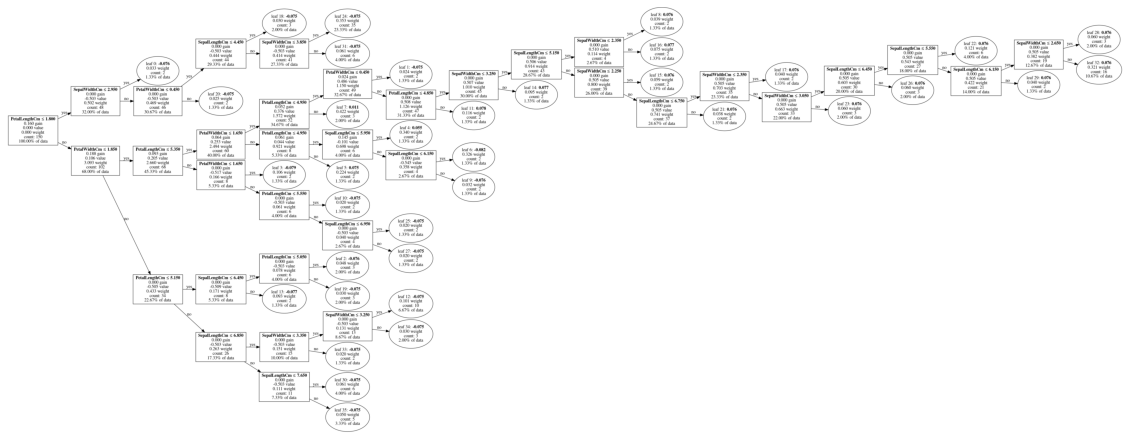

In [39]:
lgb.plot_tree(model, tree_index=int(tree_with_deepest_leaf), figsize=(20, 15), show_info=show_info)
# We count 36 ovals and 35 boxes; by now we notice that number of ovals = 1 + number of boxes.

### 7.3 Verify that total number of ovals = number of leaves

In [40]:
len(leaves.loc[ leaves['tree_index']==tree_with_deepest_leaf ])
# All good.

36

### 7.4 Verify that total number of boxes = max(split_index) + 1
We need to plus one because split_index starts from zero.

In [41]:
leaves.loc[ leaves['tree_index']==tree_with_deepest_leaf, 'split_index' ].max() + 1
# Perfect tally.

35

### 7.5 Is the deepest tree the one with most splits?

In [42]:
leaves.sort_values(by='split_index', ascending=False)
# No. 
# The deepest tree has depth=18 and max(split_index)=31. 
# The tree with most splits has depth=11 and max(split_index)=41.

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
2195,42,-0.075699,0.036588,2,77,41,11,1,3.469450e-18,3.45,<=,True,None,-0.504659,0.091469,5
2194,36,-0.075699,0.054882,3,77,41,11,1,3.469450e-18,3.45,<=,True,None,-0.504659,0.091469,5
2198,41,-0.075699,0.054882,3,77,40,9,0,3.469450e-18,5.65,<=,True,None,-0.504659,0.091469,5
2197,32,-0.075699,0.036588,2,77,40,9,0,3.469450e-18,5.65,<=,True,None,-0.504659,0.091469,5
2219,40,0.076411,0.072494,2,77,39,7,1,6.938890e-18,3.75,<=,True,None,0.509406,0.181234,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,2,-0.873612,21.777778,49,0,1,3,1,1.080880e+00,2.85,<=,True,None,1.455880,22.666700,51
193,0,0.034556,0.925018,2,12,1,3,1,3.173080e-01,2.85,<=,True,None,0.804833,24.360500,51
1321,1,0.080904,0.270589,2,51,1,3,3,2.922260e-01,0.45,<=,True,None,-0.479117,6.848590,102
0,0,-1.042362,0.888889,2,0,1,3,1,1.080880e+00,2.85,<=,True,None,1.455880,22.666700,51


### 7.6 Let's plot the tree with the highest number of splits

In [43]:
leaf_with_most_splits = leaves.loc[leaves['split_index'].argmax()]
tree_with_most_splits = leaf_with_most_splits['tree_index']

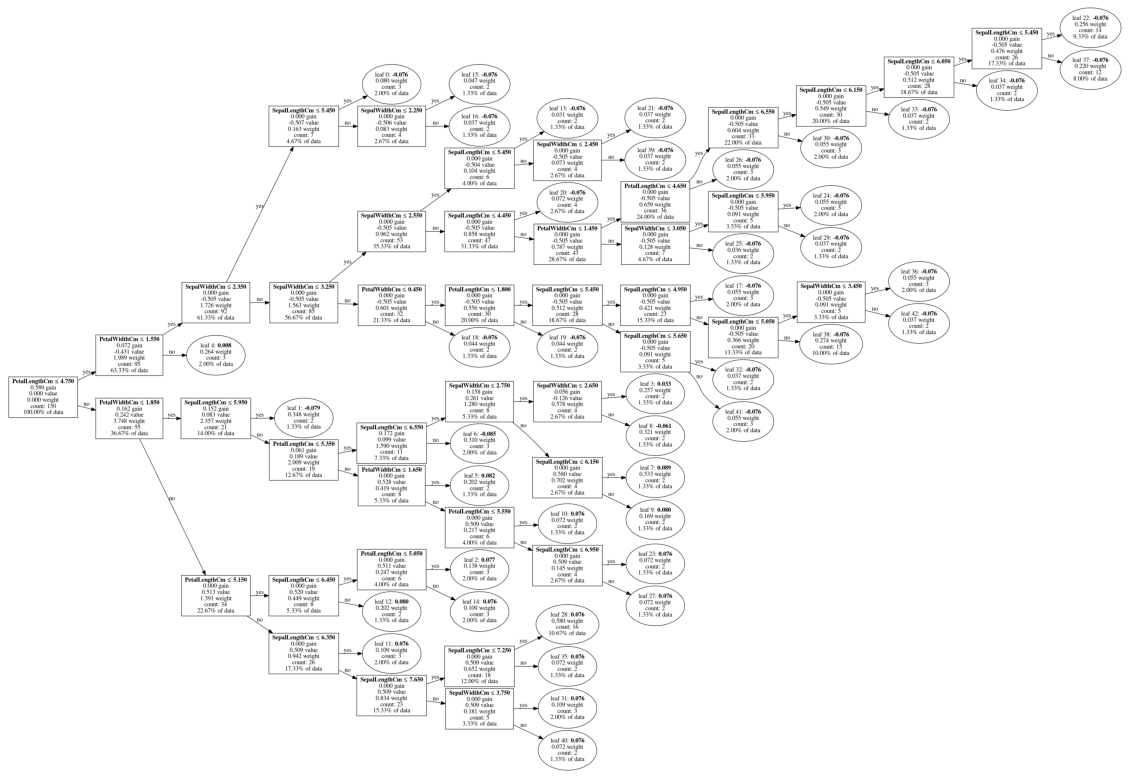

In [44]:
lgb.plot_tree(model, tree_index=int(tree_with_most_splits), figsize=(20, 15), show_info=show_info)
# We count 42 boxes and 43 ovals

### 7.7 Does the number boxes agree with max(split_index)+1?

In [45]:
leaves.loc[leaves['tree_index']==tree_with_most_splits, 'split_index'].max() + 1
# Yes!

42

7.8 Does the number of ovals agree with the number of leaves on this tree?

In [46]:
(leaves['tree_index']==tree_with_most_splits).sum()
# Yes!

43

# 8. Sister notebooks: the Leaf-by-leaf series
Decision trees: a leaf-by-leaf demo  (we are here)

https://www.kaggle.com/marychin/decision-trees-a-leaf-by-leaf-demo

**num_leaves** and **min_data_in_leaf**: a LightGBM demo

https://www.kaggle.com/marychin/num-leaves-min-data-in-leaf-a-lightgbm-demo

min_sum_hessian: a LightGBM demo

https://www.kaggle.com/marychin/min-sum-hessian-a-lightgbm-demo

feature_importances split vs gain: a demo

https://www.kaggle.com/marychin/feature-importances-split-vs-gain-a-demo

# 9. Cheers, Kagglers & Kaggle!
Together we democratise learning and skills.